✅ 2024 variables renamed successfully.
Data loaded. X: (65437, 77), y: (65437, 3)
🚀 Starting FLO pipeline... this may take several hours.
Total features being tested: 77

🔹 FLO-style importance for target: JobSat
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021552 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 997
[LightGBM] [Info] Number of data points in the train set: 52349, number of used features: 75
[LightGBM] [Info] Start training from score -2.899101
[LightGBM] [Info] Start training from score -0.391306
[LightGBM] [Info] Start training from score -1.313959
[JobSat] 50/77 features processed...
Baseline balanced_accuracy for JobSat: 0.5341
Top-25 for JobSat: ['tech_count', 'org_size', 'info_accessibility', 'cross_team_interaction', 'coding_count', 'answer_findability', 'tool_adequacy', 'developer_status', 'knowledge_silos', 'F

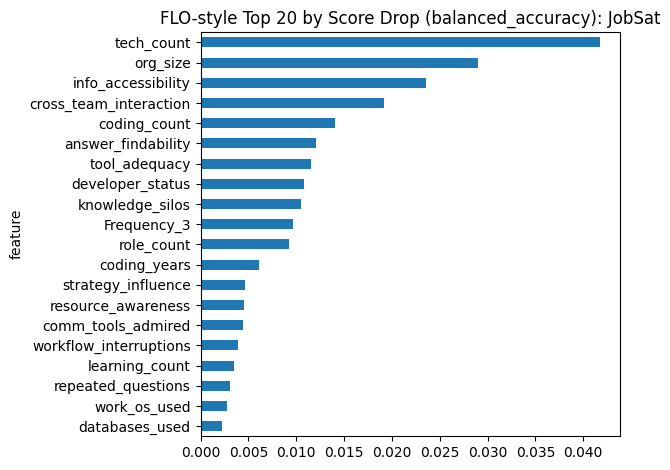

💾 Saved per-target TOP-5 dataset: devx_2024_modellingDataset_JobSat_top5.csv  shape=(65437, 6)
💾 Saved per-target TOP-5 dataset: devx_2024_modellingDataset_Frustration_top5.csv  shape=(65437, 6)
💾 Saved per-target TOP-5 dataset: devx_2024_modellingDataset_JobPerspectiveClass_top5.csv  shape=(65437, 6)
💾 Saved UNION TOP-5 dataset: devx_2024_modellingDataset_FLOtop5_union.csv  shape=(65437, 17)
Selected union features: ['ai_challenges', 'ai_tools', 'coding_count', 'coding_years', 'comm_tools_used', 'cross_team_interaction', 'databases_used', 'info_accessibility', 'languages_used', 'learning_count', 'org_size', 'so_usage', 'tech_count', 'tools_used']
💾 Saved: FLO_top5_per_target_summary.csv


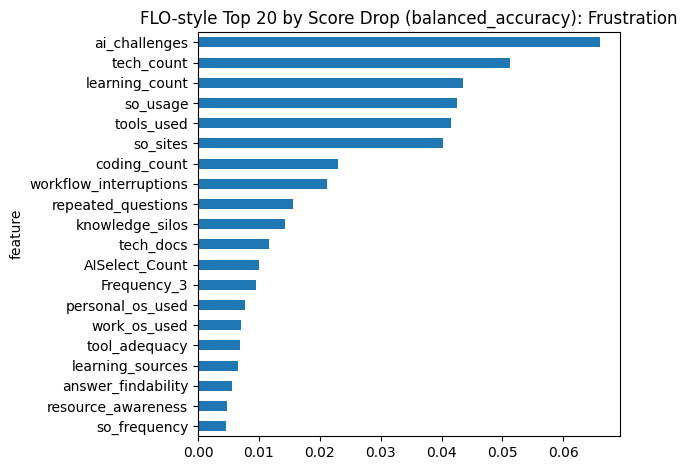

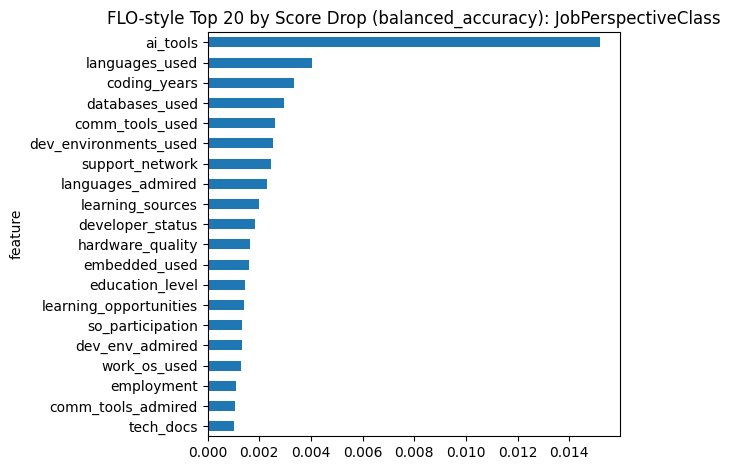

✅ FLO pipeline completed successfully. Preparing files...
['flo_importances_2024_JobSat.csv', 'flo_importances_2024_Frustration.csv', 'flo_importances_2024_JobPerspectiveClass.csv', 'FLO_selected_features_2024.csv', 'devx_2024_modellingDataset_FLOtop5_union.csv', 'FLO_full_importance_summary_2024.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================
# FLO-style feature selection (score drop via permutation) + Multi-Output LGBM
# ================================================================
!pip install lightgbm scikit-learn pandas numpy matplotlib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, accuracy_score
from sklearn.multioutput import MultiOutputClassifier
from google.colab import files

# ------------------------------
# 0) Config
# ------------------------------
CSV_PATH = "/content/devx_2024_modelling_Dataset.csv"

TARGETS   = ["JobSat", "Frustration", "JobPerspectiveClass"]
TOP_K     = 25         # pick top-K per target
N_REPEATS = 3          # # of permutations per feature for stability (increase for more stability)
RANDOM_STATE = 42

# Choose a robust metric for imbalanced multiclass
SCORE_NAME = "balanced_accuracy"

def score_fn(y_true, y_pred, average="macro"):
    if SCORE_NAME == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    elif SCORE_NAME == "macro_f1":
        return f1_score(y_true, y_pred, average=average)
    else:
        raise ValueError("Unknown SCORE_NAME")

# ------------------------------
# 1) Load & basic checks
# ------------------------------
df = pd.read_csv(CSV_PATH)
# ------------------------------
# RENAME VARIABLES
# ------------------------------

rename_map_2024 = {
    "ProfessionalTech_Count": "tech_count",
    "AIChallenges_Count": "ai_challenges",
    "Knowledge_1": "collaboration",
    "Knowledge_3": "info_access",
    "LearnCode_Count": "learning_count",
    "SOHow_Count": "so_usage",
    "CodingActivities_Count": "coding_count",
    "AIToolCurrently_Using_Count": "ai_tools"
}

df.rename(columns=rename_map_2024, inplace=True)

print("✅ 2024 variables renamed successfully.")

for t in TARGETS:
    if t not in df.columns:
        raise ValueError(f"Target '{t}' not found in file.")
df[TARGETS] = df[TARGETS].apply(pd.to_numeric, errors="coerce").astype("int64")

X = df.drop(columns=TARGETS)
y = df[TARGETS].copy()

print(f"Data loaded. X: {X.shape}, y: {y.shape}")

# Simple 80/20 split; stratify by one target to preserve imbalance pattern
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y["JobPerspectiveClass"], random_state=RANDOM_STATE
)

# ------------------------------
# 2) FLO-style permutation importance for ONE target
# ------------------------------
def flo_importance_for_target(X_train, y_train, X_valid, y_valid, target_name, n_repeats=3, random_state=42):
    """
    Train a LightGBM classifier for a single target and compute permutation-based
    score-drop importances (FLO-style). Higher drop => more important.
    """
    rng = np.random.RandomState(random_state)

    # Model (solid defaults; tweak if you like)
    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train, y_train[target_name])

    # Baseline score
    base_pred = model.predict(X_valid)
    base_score = score_fn(y_valid[target_name], base_pred)

    # Permutation loop
    drops = []
    Xv = X_valid.copy()
    cols = Xv.columns.tolist()
    for j, col in enumerate(cols):
        scores = []
        col_values = Xv[col].values.copy()
        for r in range(n_repeats):
            shuffled = col_values.copy()
            rng.shuffle(shuffled)
            Xv[col] = shuffled
            pred = model.predict(Xv)
            s = score_fn(y_valid[target_name], pred)
            scores.append(s)
        # restore column
        Xv[col] = col_values
        mean_drop = base_score - np.mean(scores)
        drops.append(mean_drop)

        if (j+1) % 50 == 0:
            print(f"[{target_name}] {j+1}/{len(cols)} features processed...")

    imp_df = pd.DataFrame({
        "feature": cols,
        "importance_drop": drops
    }).sort_values("importance_drop", ascending=False).reset_index(drop=True)

    return imp_df, base_score, model
print("🚀 Starting FLO pipeline... this may take several hours.")
print(f"Total features being tested: {X.shape[1]}")
# ------------------------------
# 3) Run FLO per target & collect top-K
# ------------------------------
rank_tables = {}
top_sets = []
for t in TARGETS:
    print(f"\n🔹 FLO-style importance for target: {t}")
    imp_df, base_score, model_t = flo_importance_for_target(
        X_tr, y_tr, X_te, y_te, target_name=t, n_repeats=N_REPEATS, random_state=RANDOM_STATE
    )
    rank_tables[t] = {"importances": imp_df, "baseline_score": base_score}
    top_feats = imp_df.head(TOP_K)["feature"].tolist()
    top_sets.append(set(top_feats))
    print(f"Baseline {SCORE_NAME} for {t}: {base_score:.4f}")
    print(f"Top-{TOP_K} for {t}: {top_feats[:10]}{' ...' if len(top_feats) > 10 else ''}")

# Union of top-K across targets
selected_features = sorted(list(set().union(*top_sets)))
print(f"\n✅ Selected {len(selected_features)} unique features (union of top-{TOP_K} per target).")

# ------------------------------
# 4) Train Multi-Output LGBM on FLO-selected features
# ------------------------------
print("\n🔹 Training MultiOutput LightGBM on FLO-selected features...")
base = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
multi = MultiOutputClassifier(base)
multi.fit(X_tr[selected_features], y_tr)

# ------------------------------
# 5) Evaluate
# ------------------------------
y_pred = multi.predict(X_te[selected_features])

for i, t in enumerate(TARGETS):
    print(f"\n==== {t} ====")
    print(classification_report(y_te[t], y_pred[:, i], digits=3))
    acc = accuracy_score(y_te[t], y_pred[:, i])
    bal = balanced_accuracy_score(y_te[t], y_pred[:, i])
    f1m = f1_score(y_te[t], y_pred[:, i], average="macro")
    print(f"Accuracy: {acc:.4f} | Balanced Acc: {bal:.4f} | Macro-F1: {f1m:.4f}")

# ------------------------------
# 6) Quick bar plot of FLO importances for first target
# ------------------------------
t0 = TARGETS[0]
rt0 = rank_tables[t0]["importances"].head(20)
rt0.plot.barh(x="feature", y="importance_drop", legend=False)
plt.gca().invert_yaxis()
plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t0}")
plt.tight_layout()
plt.show()

# ================================
# 💾 Save per-target TOP-5 datasets + UNION
#    (Paste this right after section 3 or at the end)
# ================================
TOP_SAVE_K = 5  # exactly 5 per target for deliverable

# 1) Build a map of top-5 per target from your rank_tables
top5_map = {}
for t in TARGETS:
    imp_df = rank_tables[t]["importances"]
    top5 = imp_df.head(TOP_SAVE_K)["feature"].tolist()
    top5_map[t] = top5

    # Save per-target dataset: TOP-5 features + that target column
    cols_t = [c for c in (top5 + [t]) if c in df.columns]
    out_t = f"devx_2024_modellingDataset_{t}_top5.csv"
    df[cols_t].to_csv(out_t, index=False)
    print(f"💾 Saved per-target TOP-5 dataset: {out_t}  shape={df[cols_t].shape}")

# 2) Save UNION dataset across all targets (TOP-5 each)
union_feats = sorted(set(sum(top5_map.values(), [])))
union_cols = [c for c in (union_feats + TARGETS) if c in df.columns]
reduced_df = df[union_cols].copy()
union_path = "devx_2024_modellingDataset_FLOtop5_union.csv"
reduced_df.to_csv(union_path, index=False)
print(f"💾 Saved UNION TOP-5 dataset: {union_path}  shape={reduced_df.shape}")
print("Selected union features:", union_feats)

# 3) (Optional) Save a tidy summary of selections
rows = []
for t, feats in top5_map.items():
    for rk, f in enumerate(feats, 1):
        rows.append({"target": t, "rank": rk, "feature": f})
summary_path = "FLO_top5_per_target_summary.csv"
pd.DataFrame(rows).to_csv(summary_path, index=False)
print(f"💾 Saved: {summary_path}")

# ------------------------------
# 6b) Second target
# ------------------------------
if len(TARGETS) > 1:
    t1 = TARGETS[1]
    rt1 = rank_tables[t1]["importances"].head(20)
    rt1.plot.barh(x="feature", y="importance_drop", legend=False)
    plt.gca().invert_yaxis()
    plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t1}")
    plt.tight_layout()
    plt.show()

# ------------------------------
# 6c) Third target
# ------------------------------
if len(TARGETS) > 2:
    t2 = TARGETS[2]
    rt2 = rank_tables[t2]["importances"].head(20)
    rt2.plot.barh(x="feature", y="importance_drop", legend=False)
    plt.gca().invert_yaxis()
    plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t2}")
    plt.tight_layout()
    plt.show()

# ------------------------------
# FINAL SAVE + SAFE DOWNLOAD (ZIP)
# ------------------------------

import zipfile
from google.colab import files

print("✅ FLO pipeline completed successfully. Preparing files...")

download_paths = []

# Save per-target importances
for t in TARGETS:
    path = f"flo_importances_2024_{t}.csv"
    rank_tables[t]["importances"].to_csv(path, index=False)
    download_paths.append(path)

# Selected features
selected_path = "FLO_selected_features_2024.csv"
pd.DataFrame({"feature": selected_features}).to_csv(selected_path, index=False)
download_paths.append(selected_path)

download_paths.append("devx_2024_modellingDataset_FLOtop5_union.csv")

# Master importance summary
all_rows = []
for t in TARGETS:
    tmp = rank_tables[t]["importances"].copy()
    tmp["target"] = t
    all_rows.append(tmp)

full_summary = pd.concat(all_rows)
summary_path = "FLO_full_importance_summary_2024.csv"
full_summary.to_csv(summary_path, index=False)
download_paths.append(summary_path)

# ZIP everything (SAFEST for overnight runs)
zip_name = "FLO_2024_outputs.zip"

with zipfile.ZipFile(zip_name, 'w') as z:
    for file in download_paths:
        z.write(file)
print(download_paths)

files.download(zip_name)



2025 dataset top features

Data loaded. X: (49191, 117), y: (49191, 3)

🔹 FLO-style importance for target: JobSat
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.101960 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2108
[LightGBM] [Info] Number of data points in the train set: 39352, number of used features: 117
[LightGBM] [Info] Start training from score -2.999602
[LightGBM] [Info] Start training from score -0.810689
[LightGBM] [Info] Start training from score -0.681928
[JobSat] 50/117 features processed...
[JobSat] 100/117 features processed...
Baseline balanced_accuracy for JobSat: 0.5380
Top-25 for JobSat: ['job_leadership_priority', 'career_change', 'developer_status', 'org_size', 'ai_complexity', 'employment', 'so_community_member', 'job_stability_priority', 'job_expertise_pri

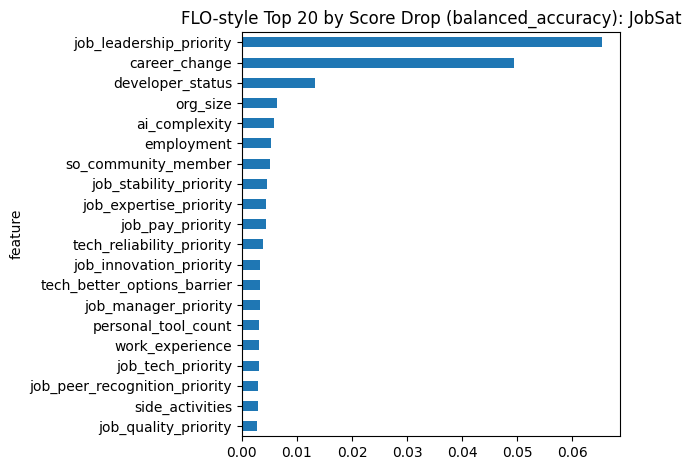

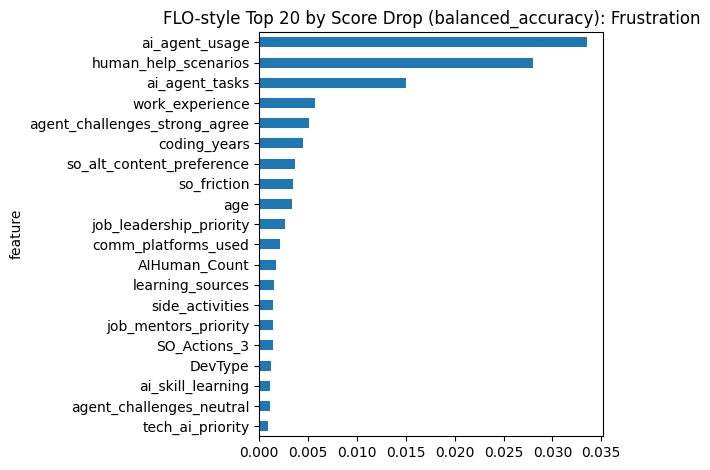

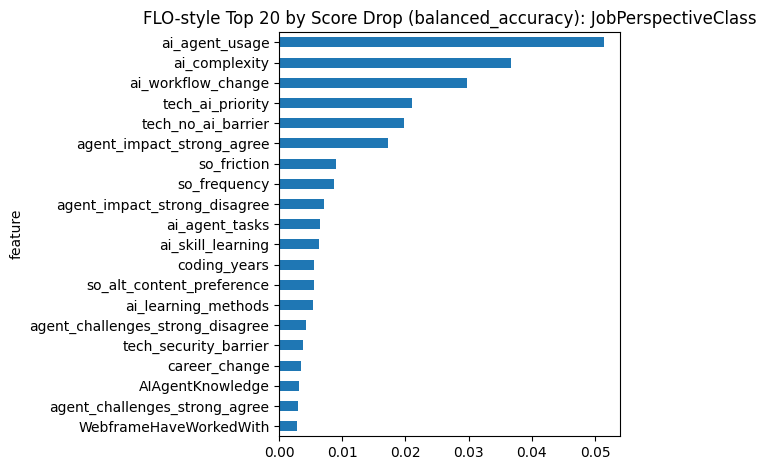

💾 Saved per-target TOP-5 dataset: devx_2025_modellingDataset_JobSat_top5.csv  shape=(49191, 6)
💾 Saved per-target TOP-5 dataset: devx_2025_modellingDataset_Frustration_top5.csv  shape=(49191, 6)
💾 Saved per-target TOP-5 dataset: devx_2025_modellingDataset_JobPerspectiveClass_top5.csv  shape=(49191, 6)
💾 Saved UNION TOP-5 dataset: devx_2025_modellingDataset_FLOtop5_union.csv  shape=(49191, 16)
Selected union features: ['agent_challenges_strong_agree', 'ai_agent_tasks', 'ai_agent_usage', 'ai_complexity', 'ai_workflow_change', 'career_change', 'developer_status', 'human_help_scenarios', 'job_leadership_priority', 'org_size', 'tech_ai_priority', 'tech_no_ai_barrier', 'work_experience']
💾 Saved: FLO_top5_per_target_summary.csv
✅ FLO pipeline completed successfully. Preparing files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================
# FLO-style feature selection (score drop via permutation) + Multi-Output LGBM
# ================================================================
!pip install lightgbm scikit-learn pandas numpy matplotlib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, accuracy_score
from sklearn.multioutput import MultiOutputClassifier

# ------------------------------
# 0) Config
# ------------------------------
CSV_PATH = "/content/devx_2025_modelling_Dataset.csv"
TARGETS   = ["JobSat", "Frustration", "JobPerspectiveClass"]
TOP_K     = 25         # pick top-K per target
N_REPEATS = 3          # # of permutations per feature for stability
RANDOM_STATE = 42

# Choose a robust metric for imbalanced multiclass
SCORE_NAME = "balanced_accuracy"

def score_fn(y_true, y_pred, average="macro"):
    if SCORE_NAME == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    elif SCORE_NAME == "macro_f1":
        return f1_score(y_true, y_pred, average=average)
    else:
        raise ValueError("Unknown SCORE_NAME")

# ------------------------------
# 1) Load & basic checks
# ------------------------------
df = pd.read_csv(CSV_PATH)
for t in TARGETS:
    if t not in df.columns:
        raise ValueError(f"Target '{t}' not found in file.")
df[TARGETS] = df[TARGETS].apply(pd.to_numeric, errors="coerce").astype("int64")

X = df.drop(columns=TARGETS)
y = df[TARGETS].copy()

print(f"Data loaded. X: {X.shape}, y: {y.shape}")

# Simple 80/20 split; stratify by one target to preserve imbalance pattern
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y["JobPerspectiveClass"], random_state=RANDOM_STATE
)

# ------------------------------
# 2) FLO-style permutation importance for ONE target
# ------------------------------
def flo_importance_for_target(X_train, y_train, X_valid, y_valid, target_name, n_repeats=3, random_state=42):
    """
    Train a LightGBM classifier for a single target and compute permutation-based
    score-drop importances (FLO-style). Higher drop => more important.
    """
    rng = np.random.RandomState(random_state)

    # Model (solid defaults; tweak if you like)
    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train, y_train[target_name])

    # Baseline score
    base_pred = model.predict(X_valid)
    base_score = score_fn(y_valid[target_name], base_pred)

    # Permutation loop
    drops = []
    Xv = X_valid.copy()
    cols = Xv.columns.tolist()
    for j, col in enumerate(cols):
        scores = []
        col_values = Xv[col].values.copy()
        for r in range(n_repeats):
            shuffled = col_values.copy()
            rng.shuffle(shuffled)
            Xv[col] = shuffled
            pred = model.predict(Xv)
            s = score_fn(y_valid[target_name], pred)
            scores.append(s)
        # restore column
        Xv[col] = col_values
        mean_drop = base_score - np.mean(scores)
        drops.append(mean_drop)

        if (j+1) % 50 == 0:
            print(f"[{target_name}] {j+1}/{len(cols)} features processed...")

    imp_df = pd.DataFrame({
        "feature": cols,
        "importance_drop": drops
    }).sort_values("importance_drop", ascending=False).reset_index(drop=True)

    return imp_df, base_score, model

# ------------------------------
# 3) Run FLO per target & collect top-K
# ------------------------------
rank_tables = {}
top_sets = []
for t in TARGETS:
    print(f"\n🔹 FLO-style importance for target: {t}")
    imp_df, base_score, model_t = flo_importance_for_target(
        X_tr, y_tr, X_te, y_te, target_name=t, n_repeats=N_REPEATS, random_state=RANDOM_STATE
    )
    rank_tables[t] = {"importances": imp_df, "baseline_score": base_score}
    top_feats = imp_df.head(TOP_K)["feature"].tolist()
    top_sets.append(set(top_feats))
    print(f"Baseline {SCORE_NAME} for {t}: {base_score:.4f}")
    print(f"Top-{TOP_K} for {t}: {top_feats[:10]}{' ...' if len(top_feats) > 10 else ''}")

# Union of top-K across targets
selected_features = sorted(list(set().union(*top_sets)))
print(f"\n✅ Selected {len(selected_features)} unique features (union of top-{TOP_K} per target).")

# ------------------------------
# 4) Train Multi-Output LGBM on FLO-selected features
# ------------------------------
print("\n🔹 Training MultiOutput LightGBM on FLO-selected features...")
base = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
multi = MultiOutputClassifier(base)
multi.fit(X_tr[selected_features], y_tr)

# ------------------------------
# 5) Evaluate
# ------------------------------
y_pred = multi.predict(X_te[selected_features])

for i, t in enumerate(TARGETS):
    print(f"\n==== {t} ====")
    print(classification_report(y_te[t], y_pred[:, i], digits=3))
    acc = accuracy_score(y_te[t], y_pred[:, i])
    bal = balanced_accuracy_score(y_te[t], y_pred[:, i])
    f1m = f1_score(y_te[t], y_pred[:, i], average="macro")
    print(f"Accuracy: {acc:.4f} | Balanced Acc: {bal:.4f} | Macro-F1: {f1m:.4f}")

# ------------------------------
# 6) Quick bar plot of FLO importances for first target
# ------------------------------
t0 = TARGETS[0]
rt0 = rank_tables[t0]["importances"].head(20)
rt0.plot.barh(x="feature", y="importance_drop", legend=False)
plt.gca().invert_yaxis()
plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t0}")
plt.tight_layout()
plt.show()
# ------------------------------
# 6b) Second target
# ------------------------------
if len(TARGETS) > 1:
    t1 = TARGETS[1]
    rt1 = rank_tables[t1]["importances"].head(20)
    rt1.plot.barh(x="feature", y="importance_drop", legend=False)
    plt.gca().invert_yaxis()
    plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t1}")
    plt.tight_layout()
    plt.show()

# ------------------------------
# 6c) Third target
# ------------------------------
if len(TARGETS) > 2:
    t2 = TARGETS[2]
    rt2 = rank_tables[t2]["importances"].head(20)
    rt2.plot.barh(x="feature", y="importance_drop", legend=False)
    plt.gca().invert_yaxis()
    plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t2}")
    plt.tight_layout()
    plt.show()


# ================================
# 💾 Save per-target TOP-5 datasets + UNION
#    (Paste this right after section 3 or at the end)
# ================================
TOP_SAVE_K = 5  # exactly 5 per target for deliverable

# 1) Build a map of top-5 per target from  the rank_tables
top5_map = {}
for t in TARGETS:
    imp_df = rank_tables[t]["importances"]
    top5 = imp_df.head(TOP_SAVE_K)["feature"].tolist()
    top5_map[t] = top5

    # Save per-target dataset: TOP-5 features + that target column
    cols_t = [c for c in (top5 + [t]) if c in df.columns]
    out_t = f"devx_2025_modellingDataset_{t}_top5.csv"
    df[cols_t].to_csv(out_t, index=False)
    print(f"💾 Saved per-target TOP-5 dataset: {out_t}  shape={df[cols_t].shape}")

# 2) Save UNION dataset across all targets (TOP-5 each)
union_feats = sorted(set(sum(top5_map.values(), [])))
union_cols = [c for c in (union_feats + TARGETS) if c in df.columns]
reduced_df = df[union_cols].copy()
union_path = "devx_2025_modellingDataset_FLOtop5_union.csv"
reduced_df.to_csv(union_path, index=False)
print(f"💾 Saved UNION TOP-5 dataset: {union_path}  shape={reduced_df.shape}")
print("Selected union features:", union_feats)

# 3) (Optional) Save a tidy summary of selections
rows = []
for t, feats in top5_map.items():
    for rk, f in enumerate(feats, 1):
        rows.append({"target": t, "rank": rk, "feature": f})
summary_path = "FLO_top5_per_target_summary.csv"
pd.DataFrame(rows).to_csv(summary_path, index=False)
print(f"💾 Saved: {summary_path}")
# ------------------------------
# FINAL SAVE + SAFE DOWNLOAD (ZIP)
# ------------------------------

import zipfile
from google.colab import files

print("✅ FLO pipeline completed successfully. Preparing files...")

download_paths = []

# Save per-target importances
for t in TARGETS:
    path = f"flo_importances_2025_{t}.csv"
    rank_tables[t]["importances"].to_csv(path, index=False)
    download_paths.append(path)

# Selected features
selected_path = "FLO_selected_features_2025.csv"
pd.DataFrame({"feature": selected_features}).to_csv(selected_path, index=False)
download_paths.append(selected_path)

download_paths.append("devx_2025_modellingDataset_FLOtop5_union.csv")
# Master importance summary
all_rows = []
for t in TARGETS:
    tmp = rank_tables[t]["importances"].copy()
    tmp["target"] = t
    all_rows.append(tmp)

full_summary = pd.concat(all_rows)
summary_path = "FLO_full_importance_summary_2025.csv"
full_summary.to_csv(summary_path, index=False)
download_paths.append(summary_path)

# ZIP everything (SAFEST for overnight runs)
zip_name = "FLO_2025_outputs.zip"

with zipfile.ZipFile(zip_name, 'w') as z:
    for file in download_paths:
        z.write(file)

files.download(zip_name)

2022 dataset top features

Data loaded. X: (73268, 50), y: (73268, 3)

🔹 FLO-style importance for target: MentalHealth
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 593
[LightGBM] [Info] Number of data points in the train set: 58614, number of used features: 50
[LightGBM] [Info] Start training from score -0.238795
[LightGBM] [Info] Start training from score -1.710969
[LightGBM] [Info] Start training from score -3.450397
[MentalHealth] 50/50 features processed...
Baseline balanced_accuracy for MentalHealth: 0.4304
Top-25 for MentalHealth: ['onboarding_speed', 'search_time', 'tech_count', 'info_accessibility', 'help_frequency', 'education_level', 'knowledge_silo_frequency', 'so_frequency', 'MiscTechHaveWorkedWith', 'answer_time'] 

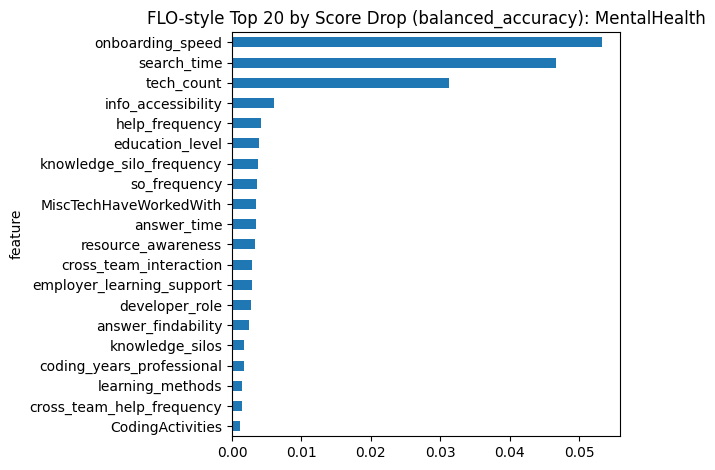

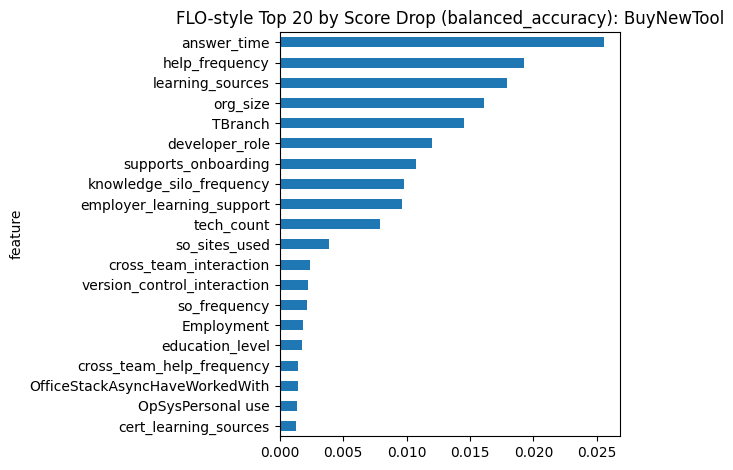

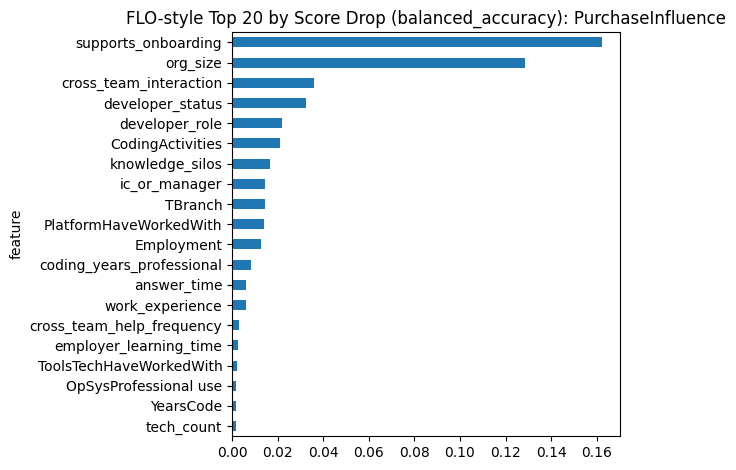

💾 Saved per-target TOP-5 dataset: devx_2022_modellingDataset_MentalHealth_top5.csv  shape=(73268, 6)
💾 Saved per-target TOP-5 dataset: devx_2022_modellingDataset_BuyNewTool_top5.csv  shape=(73268, 6)
💾 Saved per-target TOP-5 dataset: devx_2022_modellingDataset_PurchaseInfluence_top5.csv  shape=(73268, 6)
💾 Saved UNION TOP-5 dataset: devx_2022_modellingDataset_FLOtop5_union.csv  shape=(73268, 16)
Selected union features: ['TBranch', 'answer_time', 'cross_team_interaction', 'developer_role', 'developer_status', 'help_frequency', 'info_accessibility', 'learning_sources', 'onboarding_speed', 'org_size', 'search_time', 'supports_onboarding', 'tech_count']
💾 Saved: FLO_2022_top5_per_target_summary.csv
✅ Preparing 2022 files for download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================
# FLO-style feature selection (score drop via permutation) + Multi-Output LGBM
# FOR 2022 DEVX DATASET
# ================================================================
!pip install lightgbm scikit-learn pandas numpy matplotlib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, accuracy_score
from sklearn.multioutput import MultiOutputClassifier

# ------------------------------
# 0) Config
# ------------------------------
CSV_PATH = "/content/devx_2022_modelling_Dataset.csv"
TARGETS   = ["MentalHealth", "BuyNewTool", "PurchaseInfluence"]
TOP_K     = 25         # pick top-K per target
N_REPEATS = 3          # # of permutations per feature for stability
RANDOM_STATE = 42

# Choose a robust metric for imbalanced multiclass
SCORE_NAME = "balanced_accuracy"

def score_fn(y_true, y_pred, average="macro"):
    if SCORE_NAME == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    elif SCORE_NAME == "macro_f1":
        return f1_score(y_true, y_pred, average=average)
    else:
        raise ValueError("Unknown SCORE_NAME")

# ------------------------------
# 1) Load & basic checks
# ------------------------------
df = pd.read_csv(CSV_PATH)

for t in TARGETS:
    if t not in df.columns:
        raise ValueError(f"Target '{t}' not found in file.")

# ensure integer type
df[TARGETS] = df[TARGETS].apply(pd.to_numeric, errors="coerce").astype("int64")

X = df.drop(columns=TARGETS)
y = df[TARGETS].copy()

print(f"Data loaded. X: {X.shape}, y: {y.shape}")

# Simple 80/20 split; stratify by one target (emotion dimension)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y["MentalHealth"], random_state=RANDOM_STATE
)

# ------------------------------
# 2) FLO-style permutation importance for ONE target
# ------------------------------
def flo_importance_for_target(X_train, y_train, X_valid, y_valid,
                              target_name, n_repeats=3, random_state=42):
    """
    Train a LightGBM classifier for a single target and compute permutation-based
    score-drop importances (FLO-style). Higher drop => more important.
    """
    rng = np.random.RandomState(random_state)

    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train, y_train[target_name])

    # Baseline score
    base_pred = model.predict(X_valid)
    base_score = score_fn(y_valid[target_name], base_pred)

    drops = []
    Xv = X_valid.copy()
    cols = Xv.columns.tolist()

    for j, col in enumerate(cols):
        scores = []
        col_values = Xv[col].values.copy()

        for r in range(n_repeats):
            shuffled = col_values.copy()
            rng.shuffle(shuffled)
            Xv[col] = shuffled
            pred = model.predict(Xv)
            s = score_fn(y_valid[target_name], pred)
            scores.append(s)

        # restore
        Xv[col] = col_values
        mean_drop = base_score - np.mean(scores)
        drops.append(mean_drop)

        if (j + 1) % 50 == 0:
            print(f"[{target_name}] {j+1}/{len(cols)} features processed...")

    imp_df = pd.DataFrame({
        "feature": cols,
        "importance_drop": drops
    }).sort_values("importance_drop", ascending=False).reset_index(drop=True)

    return imp_df, base_score, model

# ------------------------------
# 3) Run FLO per target & collect top-K
# ------------------------------
rank_tables = {}
top_sets = []

for t in TARGETS:
    print(f"\n🔹 FLO-style importance for target: {t}")
    imp_df, base_score, model_t = flo_importance_for_target(
        X_tr, y_tr, X_te, y_te,
        target_name=t,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE
    )
    rank_tables[t] = {"importances": imp_df, "baseline_score": base_score}
    top_feats = imp_df.head(TOP_K)["feature"].tolist()
    top_sets.append(set(top_feats))

    print(f"Baseline {SCORE_NAME} for {t}: {base_score:.4f}")
    print(f"Top-{TOP_K} for {t}: {top_feats[:10]}{' ...' if len(top_feats) > 10 else ''}")

# Union of top-K across targets
selected_features = sorted(list(set().union(*top_sets)))
print(f"\n✅ Selected {len(selected_features)} unique features (union of top-{TOP_K} per target).")

# ------------------------------
# 4) Train Multi-Output LGBM on FLO-selected features
# ------------------------------
print("\n🔹 Training MultiOutput LightGBM on FLO-selected features...")
base = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
multi = MultiOutputClassifier(base)
multi.fit(X_tr[selected_features], y_tr)

# ------------------------------
# 5) Evaluate
# ------------------------------
y_pred = multi.predict(X_te[selected_features])

for i, t in enumerate(TARGETS):
    print(f"\n==== {t} ====")
    print(classification_report(y_te[t], y_pred[:, i], digits=3))
    acc = accuracy_score(y_te[t], y_pred[:, i])
    bal = balanced_accuracy_score(y_te[t], y_pred[:, i])
    f1m = f1_score(y_te[t], y_pred[:, i], average="macro")
    print(f"Accuracy: {acc:.4f} | Balanced Acc: {bal:.4f} | Macro-F1: {f1m:.4f}")

# ------------------------------
# 6) FLO bar plots
# ------------------------------
# 6a) First target
t0 = TARGETS[0]
rt0 = rank_tables[t0]["importances"].head(20)
rt0.plot.barh(x="feature", y="importance_drop", legend=False)
plt.gca().invert_yaxis()
plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t0}")
plt.tight_layout()
plt.show()

# 6b) Second target
if len(TARGETS) > 1:
    t1 = TARGETS[1]
    rt1 = rank_tables[t1]["importances"].head(20)
    rt1.plot.barh(x="feature", y="importance_drop", legend=False)
    plt.gca().invert_yaxis()
    plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t1}")
    plt.tight_layout()
    plt.show()

# 6c) Third target
if len(TARGETS) > 2:
    t2 = TARGETS[2]
    rt2 = rank_tables[t2]["importances"].head(20)
    rt2.plot.barh(x="feature", y="importance_drop", legend=False)
    plt.gca().invert_yaxis()
    plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t2}")
    plt.tight_layout()
    plt.show()

# ================================
# 8) Save per-target TOP-5 datasets + UNION (for reporting)
# ================================
TOP_SAVE_K = 5  # exactly 5 per target for deliverable

top5_map = {}
for t in TARGETS:
    imp_df = rank_tables[t]["importances"]
    top5 = imp_df.head(TOP_SAVE_K)["feature"].tolist()
    top5_map[t] = top5

    cols_t = [c for c in (top5 + [t]) if c in df.columns]
    out_t = f"devx_2022_modellingDataset_{t}_top5.csv"
    df[cols_t].to_csv(out_t, index=False)
    print(f"💾 Saved per-target TOP-5 dataset: {out_t}  shape={df[cols_t].shape}")

# UNION dataset across all targets (TOP-5 each)
union_feats = sorted(set(sum(top5_map.values(), [])))
union_cols = [c for c in (union_feats + TARGETS) if c in df.columns]
reduced_df = df[union_cols].copy()
union_path = "devx_2022_modellingDataset_FLOtop5_union.csv"
reduced_df.to_csv(union_path, index=False)
print(f"💾 Saved UNION TOP-5 dataset: {union_path}  shape={reduced_df.shape}")
print("Selected union features:", union_feats)

# tidy summary of selections
rows = []
for t, feats in top5_map.items():
    for rk, f in enumerate(feats, 1):
        rows.append({"target": t, "rank": rk, "feature": f})
summary_path = "FLO_2022_top5_per_target_summary.csv"
pd.DataFrame(rows).to_csv(summary_path, index=False)
print(f"💾 Saved: {summary_path}")

# ------------------------------
# FINAL SAVE + ZIP DOWNLOAD (2022)
# ------------------------------

import zipfile
from google.colab import files

print("✅ Preparing 2022 files for download...")

download_paths = []

# Save per-target importances
for t in TARGETS:
    path = f"flo_importances_2022_{t}.csv"
    rank_tables[t]["importances"].to_csv(path, index=False)
    download_paths.append(path)

# Selected features list
selected_path = "FLO_selected_features_2022.csv"
pd.DataFrame({"feature": selected_features}).to_csv(selected_path, index=False)
download_paths.append(selected_path)

download_paths.append("devx_2022_modellingDataset_FLOtop5_union.csv")

# Master importance summary
all_rows = []
for t in TARGETS:
    tmp = rank_tables[t]["importances"].copy()
    tmp["target"] = t
    all_rows.append(tmp)

full_summary = pd.concat(all_rows)
summary_path = "FLO_full_importance_summary_2022.csv"
full_summary.to_csv(summary_path, index=False)
download_paths.append(summary_path)

# ZIP everything
zip_name = "FLO_2022_outputs.zip"

with zipfile.ZipFile(zip_name, 'w') as z:
    for file in download_paths:
        z.write(file)

files.download(zip_name)


drop tbranch 2022

✅ Dropped feature: TBranch
Data loaded. X: (73268, 49), y: (73268, 3)

🔹 FLO-style importance for target: MentalHealth
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 591
[LightGBM] [Info] Number of data points in the train set: 58614, number of used features: 49
[LightGBM] [Info] Start training from score -0.238795
[LightGBM] [Info] Start training from score -1.710969
[LightGBM] [Info] Start training from score -3.450397
Baseline balanced_accuracy for MentalHealth: 0.4293
Top-25 for MentalHealth: ['onboarding_speed', 'search_time', 'tech_count', 'info_accessibility', 'help_frequency', 'developer_role', 'cross_team_interaction', 'education_level', 'knowledge_silo_frequency', 'answer_time'] ...

🔹 FLO-sty

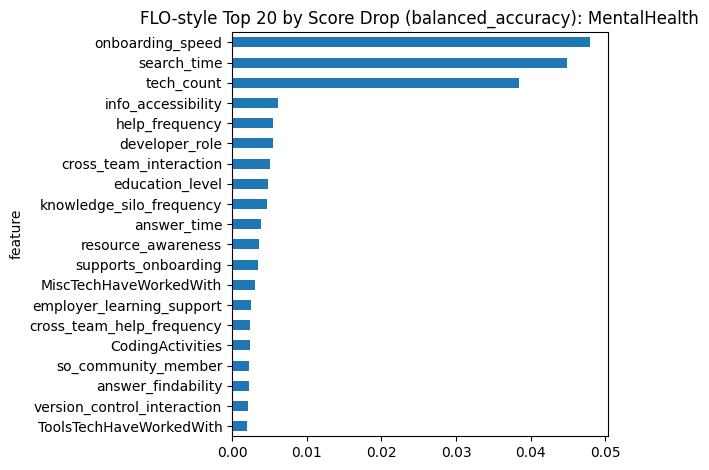

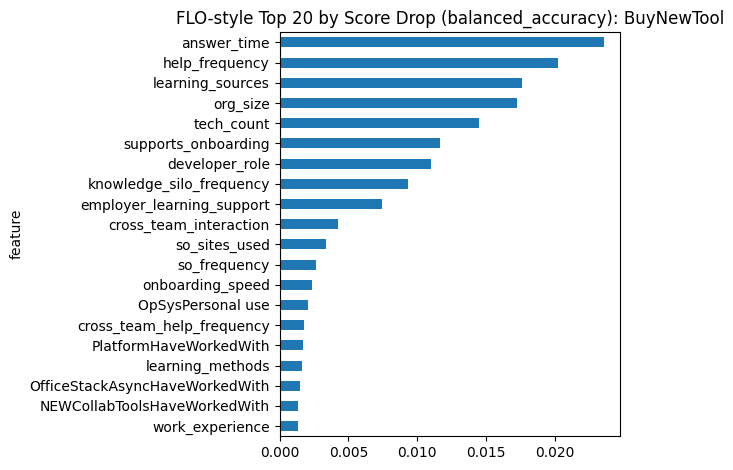

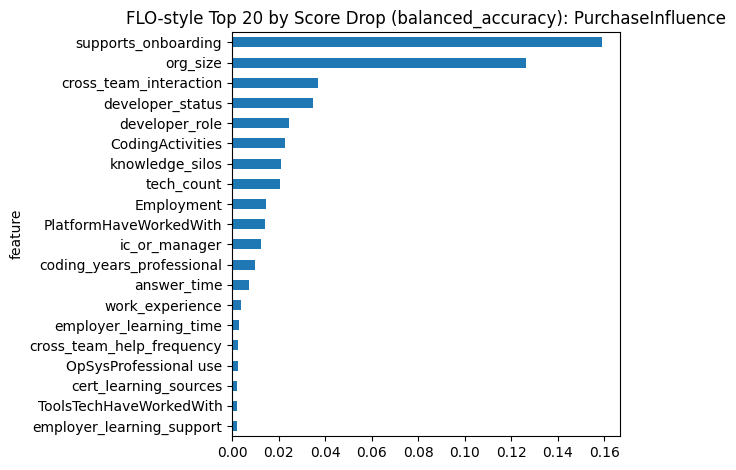

💾 Saved per-target TOP-5 dataset: devx_2022_modellingDataset_MentalHealth_top5.csv  shape=(73268, 6)
💾 Saved per-target TOP-5 dataset: devx_2022_modellingDataset_BuyNewTool_top5.csv  shape=(73268, 6)
💾 Saved per-target TOP-5 dataset: devx_2022_modellingDataset_PurchaseInfluence_top5.csv  shape=(73268, 6)
💾 Saved UNION TOP-5 dataset: devx_2022_modellingDataset_FLOtop5_union.csv  shape=(73268, 15)
Selected union features: ['answer_time', 'cross_team_interaction', 'developer_role', 'developer_status', 'help_frequency', 'info_accessibility', 'learning_sources', 'onboarding_speed', 'org_size', 'search_time', 'supports_onboarding', 'tech_count']
💾 Saved: FLO_2022_top5_per_target_summary.csv
✅ Preparing 2022 files for download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================
# FLO-style feature selection (score drop via permutation) + Multi-Output LGBM
# FOR 2022 DEVX DATASET
# ================================================================
!pip install lightgbm scikit-learn pandas numpy matplotlib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, accuracy_score
from sklearn.multioutput import MultiOutputClassifier

# ------------------------------
# 0) Config
# ------------------------------
CSV_PATH = "/content/devx_2022_modelling_Dataset.csv"
TARGETS   = ["MentalHealth", "BuyNewTool", "PurchaseInfluence"]
TOP_K     = 25         # pick top-K per target
N_REPEATS = 3          # # of permutations per feature for stability
RANDOM_STATE = 42

# Choose a robust metric for imbalanced multiclass
SCORE_NAME = "balanced_accuracy"

def score_fn(y_true, y_pred, average="macro"):
    if SCORE_NAME == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    elif SCORE_NAME == "macro_f1":
        return f1_score(y_true, y_pred, average=average)
    else:
        raise ValueError("Unknown SCORE_NAME")

# ------------------------------
# 1) Load & basic checks
# ------------------------------
df = pd.read_csv(CSV_PATH)

# ------------------------------------------------
# Drop any remaining unwanted feature
# ------------------------------------------------
if "TBranch" in df.columns:
    df = df.drop(columns=["TBranch"])
    print("✅ Dropped feature: TBranch")
else:
    print("⚠️ TBranch not found — skipping drop.")

for t in TARGETS:
    if t not in df.columns:
        raise ValueError(f"Target '{t}' not found in file.")

# ensure integer type
df[TARGETS] = df[TARGETS].apply(pd.to_numeric, errors="coerce").astype("int64")

X = df.drop(columns=TARGETS)
y = df[TARGETS].copy()

print(f"Data loaded. X: {X.shape}, y: {y.shape}")

# Simple 80/20 split; stratify by one target (emotion dimension)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y["MentalHealth"], random_state=RANDOM_STATE
)

# ------------------------------
# 2) FLO-style permutation importance for ONE target
# ------------------------------
def flo_importance_for_target(X_train, y_train, X_valid, y_valid,
                              target_name, n_repeats=3, random_state=42):
    """
    Train a LightGBM classifier for a single target and compute permutation-based
    score-drop importances (FLO-style). Higher drop => more important.
    """
    rng = np.random.RandomState(random_state)

    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train, y_train[target_name])

    # Baseline score
    base_pred = model.predict(X_valid)
    base_score = score_fn(y_valid[target_name], base_pred)

    drops = []
    Xv = X_valid.copy()
    cols = Xv.columns.tolist()

    for j, col in enumerate(cols):
        scores = []
        col_values = Xv[col].values.copy()

        for r in range(n_repeats):
            shuffled = col_values.copy()
            rng.shuffle(shuffled)
            Xv[col] = shuffled
            pred = model.predict(Xv)
            s = score_fn(y_valid[target_name], pred)
            scores.append(s)

        # restore
        Xv[col] = col_values
        mean_drop = base_score - np.mean(scores)
        drops.append(mean_drop)

        if (j + 1) % 50 == 0:
            print(f"[{target_name}] {j+1}/{len(cols)} features processed...")

    imp_df = pd.DataFrame({
        "feature": cols,
        "importance_drop": drops
    }).sort_values("importance_drop", ascending=False).reset_index(drop=True)

    return imp_df, base_score, model

# ------------------------------
# 3) Run FLO per target & collect top-K
# ------------------------------
rank_tables = {}
top_sets = []

for t in TARGETS:
    print(f"\n🔹 FLO-style importance for target: {t}")
    imp_df, base_score, model_t = flo_importance_for_target(
        X_tr, y_tr, X_te, y_te,
        target_name=t,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE
    )
    rank_tables[t] = {"importances": imp_df, "baseline_score": base_score}
    top_feats = imp_df.head(TOP_K)["feature"].tolist()
    top_sets.append(set(top_feats))

    print(f"Baseline {SCORE_NAME} for {t}: {base_score:.4f}")
    print(f"Top-{TOP_K} for {t}: {top_feats[:10]}{' ...' if len(top_feats) > 10 else ''}")

# Union of top-K across targets
selected_features = sorted(list(set().union(*top_sets)))
print(f"\n✅ Selected {len(selected_features)} unique features (union of top-{TOP_K} per target).")

# ------------------------------
# 4) Train Multi-Output LGBM on FLO-selected features
# ------------------------------
print("\n🔹 Training MultiOutput LightGBM on FLO-selected features...")
base = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
multi = MultiOutputClassifier(base)
multi.fit(X_tr[selected_features], y_tr)

# ------------------------------
# 5) Evaluate
# ------------------------------
y_pred = multi.predict(X_te[selected_features])

for i, t in enumerate(TARGETS):
    print(f"\n==== {t} ====")
    print(classification_report(y_te[t], y_pred[:, i], digits=3))
    acc = accuracy_score(y_te[t], y_pred[:, i])
    bal = balanced_accuracy_score(y_te[t], y_pred[:, i])
    f1m = f1_score(y_te[t], y_pred[:, i], average="macro")
    print(f"Accuracy: {acc:.4f} | Balanced Acc: {bal:.4f} | Macro-F1: {f1m:.4f}")

# ------------------------------
# 6) FLO bar plots
# ------------------------------
# 6a) First target
t0 = TARGETS[0]
rt0 = rank_tables[t0]["importances"].head(20)
rt0.plot.barh(x="feature", y="importance_drop", legend=False)
plt.gca().invert_yaxis()
plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t0}")
plt.tight_layout()
plt.show()

# 6b) Second target
if len(TARGETS) > 1:
    t1 = TARGETS[1]
    rt1 = rank_tables[t1]["importances"].head(20)
    rt1.plot.barh(x="feature", y="importance_drop", legend=False)
    plt.gca().invert_yaxis()
    plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t1}")
    plt.tight_layout()
    plt.show()

# 6c) Third target
if len(TARGETS) > 2:
    t2 = TARGETS[2]
    rt2 = rank_tables[t2]["importances"].head(20)
    rt2.plot.barh(x="feature", y="importance_drop", legend=False)
    plt.gca().invert_yaxis()
    plt.title(f"FLO-style Top 20 by Score Drop ({SCORE_NAME}): {t2}")
    plt.tight_layout()
    plt.show()

# ================================
# 8) Save per-target TOP-5 datasets + UNION (for reporting)
# ================================
TOP_SAVE_K = 5  # exactly 5 per target for deliverable

top5_map = {}
for t in TARGETS:
    imp_df = rank_tables[t]["importances"]
    top5 = imp_df.head(TOP_SAVE_K)["feature"].tolist()
    top5_map[t] = top5

    cols_t = [c for c in (top5 + [t]) if c in df.columns]
    out_t = f"devx_2022_modellingDataset_{t}_top5.csv"
    df[cols_t].to_csv(out_t, index=False)
    print(f"💾 Saved per-target TOP-5 dataset: {out_t}  shape={df[cols_t].shape}")

# UNION dataset across all targets (TOP-5 each)
union_feats = sorted(set(sum(top5_map.values(), [])))
union_cols = [c for c in (union_feats + TARGETS) if c in df.columns]
reduced_df = df[union_cols].copy()
union_path = "devx_2022_modellingDataset_FLOtop5_union.csv"
reduced_df.to_csv(union_path, index=False)
print(f"💾 Saved UNION TOP-5 dataset: {union_path}  shape={reduced_df.shape}")
print("Selected union features:", union_feats)

# tidy summary of selections
rows = []
for t, feats in top5_map.items():
    for rk, f in enumerate(feats, 1):
        rows.append({"target": t, "rank": rk, "feature": f})
summary_path = "FLO_2022_top5_per_target_summary.csv"
pd.DataFrame(rows).to_csv(summary_path, index=False)
print(f"💾 Saved: {summary_path}")

# ------------------------------
# FINAL SAVE + ZIP DOWNLOAD (2022)
# ------------------------------

import zipfile
from google.colab import files

print("✅ Preparing 2022 files for download...")

download_paths = []

# Save per-target importances
for t in TARGETS:
    path = f"flo_importances_2022_{t}.csv"
    rank_tables[t]["importances"].to_csv(path, index=False)
    download_paths.append(path)

# Selected features list
selected_path = "FLO_selected_features_2022.csv"
pd.DataFrame({"feature": selected_features}).to_csv(selected_path, index=False)
download_paths.append(selected_path)

download_paths.append("devx_2022_modellingDataset_FLOtop5_union.csv")

# Master importance summary
all_rows = []
for t in TARGETS:
    tmp = rank_tables[t]["importances"].copy()
    tmp["target"] = t
    all_rows.append(tmp)

full_summary = pd.concat(all_rows)
summary_path = "FLO_full_importance_summary_2022.csv"
full_summary.to_csv(summary_path, index=False)
download_paths.append(summary_path)

# ZIP everything
zip_name = "FLO_2022_outputs_new.zip"

with zipfile.ZipFile(zip_name, 'w') as z:
    for file in download_paths:
        z.write(file)

files.download(zip_name)
